# Online retail data mining
Hello and welcome to my first data mining project. My name is __[Andreas Parasian](https://www.linkedin.com/in/andreasparasian/)__. I'm currently an undergraduate student of Universitas Indonesia that is highly interested in extracting useful insights from data. Now enough about me. For this data mining project, I will be using the publicly available dataset: __[Online retail II](https://archive.ics.uci.edu/ml/datasets/Online+Retail+II)__ from __[UCI](https://uci.edu/)__. I want to say thank you to UCI because without the dataset then this whole project will not even cross my mind.<br>

This project will be done in the form of a data mining study case. Most of the project's business details are derived from the dataset description. However, the business problems and goals that this project wants to solve/achieve are going to be assumed by me through some secondary researches. Therefore, the problems and goals of this project is limited to my knowledge and research results of this study case's business domain.<br>

The approach we're using in this data mining study case is the CRISP-DM process, specifically the one mentioned in __[Page 75, Meta S. Brown, Data Mining For Dummies, Wiley Publishing Inc. (2014)](https://www.wiley.com/en-us/Data+Mining+For+Dummies-p-9781118893166)__.

In [1]:
# Importing libraries and utility functions
import os
from pathlib import Path

# Importing several important libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
sns.set(color_codes = True)

import matplotlib
%matplotlib inline
from matplotlib import pyplot as plt

# a function to print a full df once
def print_full(x):
    pd.set_option('display.max_rows', len(x))
    print(x)
    pd.reset_option('display.max_rows')

# Get the current python notebook path
ipynb_path = Path().parent.absolute()
ipynb_path = ipynb_path.as_posix()

# Business Understanding

You are a data miner working on an **online retail company** that is based on the **United Kingdom**. The company mainly sells unique **all-occasion** gift-ware. Many customers of the company are **wholesalers**. The date now is December 18th, 2011. Its the end of the 2011 operating year. Your boss gives you database access to the company's last 2 years sales data.

## Business goals
Your boss is currently asking you to do the following things:
1. seek opportunities of improvement on the company offerings to its existing customer bases.
2. forecast the number of sales next year.

## Situation assessment
In late 2011, UK residents and businesses are just recovering from the __[2007-2010 recession](https://www.ncbi.nlm.nih.gov/pmc/articles/PMC5435781/)__. Based on the article, it is known that the UK economy had a full recovery after the recession in 2010 with no significant after-effects.<br>

,Year,Yearly revenue generated from each customer
0,2009,39.610185
1,2010,34.883542
2,2011,35.715972


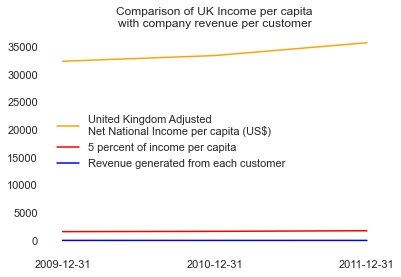

In [2]:
# Read the excel file
income_data = pd.read_excel(r'{}/API_NY.ADJ.NNTY.PC.CD_DS2_en_excel_v2_1740449.xls'.format(ipynb_path), sheet_name='Data', skiprows = [0,1,2])

# Get the income data that is required for comparison
UK_income_data = income_data[income_data['Country Name'] == 'United Kingdom'].loc[79, ['2009','2010', '2011']].reset_index()
UK_income_data = UK_income_data.rename(columns = {'index': 'year', 79: 'United Kingdom Adjusted Net National Income per capita (US$)'})

# A good practice in changing a whole column's rows is by using a mask (this is done to clarify the user and pandas interpretation), like this:
mask = UK_income_data.loc[:, ['year']].apply(lambda year: year + '-12-31')
UK_income_data.loc[:, ['year']] = mask
UK_income_data['year'] = pd.to_datetime(UK_income_data['year'], format = '%Y-%m-%d')



# Get the retail dataset that is used for the data mining project
Retail_dataset = pd.read_csv(r"{}/online_retail_II.csv".format(ipynb_path))

# Clean the dataset by dropping some irrelevant columns
Retail_dataset.drop(labels = Retail_dataset.columns[0], axis = 1, inplace = True)

# Change the InvoiceDate column dtypes into its appropriate dtype
Retail_dataset['InvoiceDate'] = pd.to_datetime(Retail_dataset['InvoiceDate'], format = '%Y-%m-%d %H:%M:%S')

# Create a revenue column from multiplying the quantity and price column, group it by country names, get the UK data
# then convert the revenue column from sterling to US$; based on the 2011 exchange rate for comparison with 2009-2011 national income

Retail_dataset['Revenue'] = Retail_dataset['Quantity']*Retail_dataset['Price']
UK_retail_data = Retail_dataset.groupby('Country').get_group('United Kingdom')

# A good practice in changing a whole column's rows is by using a mask (this is done to clarify the user and pandas interpretation), like this:
mask = UK_retail_data.loc[:, ['Revenue']].apply(lambda revenue: revenue * 1.6041)
UK_retail_data_adjusted = UK_retail_data.copy()
UK_retail_data_adjusted.loc[:, ['Revenue']] = mask

# Then get the revenues and number of customers yearly summary on each invoice date from UK
UK_sales_revenue_data = UK_retail_data_adjusted.groupby(pd.Grouper(key = 'InvoiceDate', freq = 'Y'))[['Revenue']].sum()
UK_number_of_customers_data = UK_retail_data_adjusted.groupby(pd.Grouper(key = 'InvoiceDate', freq = 'Y'))[['Customer ID']].count()

# Get the revenues generated from each customer yearly summary
UK_sales_revenue_data['Revenue'] = UK_sales_revenue_data['Revenue'] / UK_number_of_customers_data['Customer ID']



# comparing the revenues and income data by plotting them together
import matplotlib.pyplot as plt
import matplotlib.dates as mdates # important for plotting time series

fig = plt.figure()

ax1 = fig.add_subplot(1,1,1)
ax1.set_title('Comparison of UK Income per capita\nwith company revenue per customer')
ax1.set_facecolor("white")
ax1.grid(False)

ax1.set_xticks(UK_income_data['year'].tolist())
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))

ax1 = plt.plot(UK_income_data['year'], UK_income_data.iloc[:, 1], color = 'orange', label = 'United Kingdom Adjusted\nNet National Income per capita (US$)')
data_5_percent = UK_income_data.iloc[:, 1].apply(lambda revenue: revenue * 0.05)
ax1 = plt.plot(UK_income_data['year'], data_5_percent, color = 'red', label = '5 percent of income per capita')
ax1 = plt.plot(UK_sales_revenue_data.index, UK_sales_revenue_data['Revenue'], color = 'blue', label = 'Revenue generated from each customer')

# Setting the legend to be right on top of the plot
plt.legend(bbox_to_anchor=[0, 0.5], loc='center left', facecolor = 'None', edgecolor = 'None')

UK_sales_revenue_data = UK_sales_revenue_data.reset_index()
mask = UK_sales_revenue_data['InvoiceDate'].apply(lambda date: date.year)
UK_sales_revenue_data['InvoiceDate'] = mask
UK_sales_revenue_data = UK_sales_revenue_data.rename(columns = {"InvoiceDate" : "Year",
                                                                "Revenue" : "Yearly revenue generated from each customer"})

# delete the dataframe from memory since the dataset import function is going to be shown in the data preparation step.
del(Retail_dataset)

# print a dataframe with jupyter's rich-display of pandas dataframes
display(UK_sales_revenue_data)
print('\n\n')

plt.show()

By plotting and comparing the company's revenue generated from each customer and UK's recovering income per capita, it can roughly be estimated that the company's **share of customer wallet is below 5%** and isn't affected by the recovering economy. This means: even though UK's economy is recovering (the income per capita is rising), customers demand for the company's products aren't affected.<br>

Since most of the company's customers are wholesalers and most of the time they sell the bought products to another business such as another retailer whose consumers are end users, the low demand indicates an unhealthy situation for the gift-ware industry. However, gift-wares aren't neccesity goods so its also probable that end users aren't interested in buying gift-wares, especially when the economy has just recovered from a recession.<br>

Nevertheless, this period of post-recession may provide an opportunity for the company. It has been researched that __[during a recession, customers tend to search for more value rather than switching](https://link.springer.com/article/10.1057/dddmp.2010.27)__ (Ginn, J, Stone, M & Ekinci, Y 2010). Also, it is estimated that the cost of acquiring a new customer is six times more expensive than retaining an existing one. Therefore, the company can benefit from a predictive modelling technique to manage customer retention by estimating customers' probability of stay or churn over a specified period of time (Ginn, J, Stone, M & Ekinci, Y 2010). The technique can also be combined with marketing metrics, such as profitability per customer and lifetime of each customer, so as to design a **tailor-made retention strategy whenever a churn probability appears**. These retention strategies can be personalized and vary on the basis of, for example, customer value.

## Redefining business goals
After reporting and discussing the situation assessment with your boss, the business goals are redefined into a much more tangible, broader goal. Now, the company is aiming to **maintain at least 90% of the company's existing customer bases** next year.

## Defining data mining goals
Based on the business goal, the data mining goals are then defined as:
1. Identify marketing metrics to measure attrition rates for the company's existing customer bases.
2. Develop models to identify or classify which customers are at greatest risk of churning.

## Data mining project plan
Outlined here is the project plan:<br>
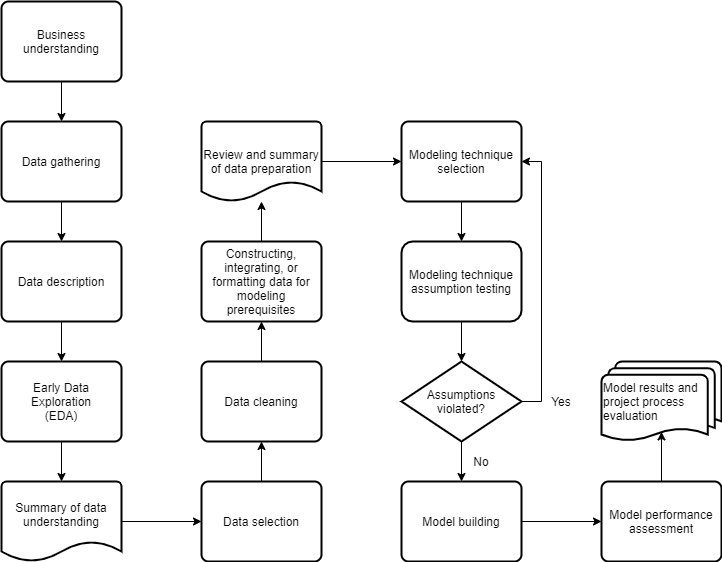

# Data understanding

## Data gathering
Because the database access to the required data has been given by the boss, the only part needed to complete this task would be to query the data from the database. As this project focuses on data mining, then for simplicity this part is considered done. It's assumed that the queried data at hand are now in the format of csv (Comma-separated values).

## Data description
The dataset comprises the company's e-commerce point of sale (POS) system historical data. __[Point of sale refers to the place where a customer executes the payment for goods or services and where sales taxes may become payable](https://www.investopedia.com/terms/p/point-of-sale.asp)__ or, in brief, refers to a stage in a transaction (online or offline) where payment invoice become receipt (Hayes, A & Estevez, E 2020). The company **allows customers to cancel their transactions/orders** (in this case, the Invoice code will start with a 'C'), hence marking their invoices as cancelled invoices. The transaction itself is **paid online and the ordered product/item is shipped to the customer location**.

## Early Data Exploration (EDA)

In [3]:
# Reading the downloaded dataset into memory then turning it into csv for faster reading.
# The code for reading then turning to csv format with the same file name =
'''
Retail_dataset = pd.read_excel("C:/Users/Torivor/OneDrive/Documents/Individual projects/Online retail analysis/online_retail_II.xlsx",
                              engine = "openpyxl",
                              sheet_name = None)

Retail_dataset = Retail_dataset['Year 2009-2010'].append(Retail_dataset['Year 2010-2011'], ignore_index=True)

Retail_dataset.to_csv("C:/Users/Torivor/OneDrive/Documents/Individual projects/Online retail analysis/online_retail_II.csv")
'''

'\nRetail_dataset = pd.read_excel("C:/Users/Torivor/OneDrive/Documents/Individual projects/Online retail analysis/online_retail_II.xlsx",\n                              engine = "openpyxl",\n                              sheet_name = None)\n\nRetail_dataset = Retail_dataset[\'Year 2009-2010\'].append(Retail_dataset[\'Year 2010-2011\'], ignore_index=True)\n\nRetail_dataset.to_csv("C:/Users/Torivor/OneDrive/Documents/Individual projects/Online retail analysis/online_retail_II.csv")\n'

In [4]:
# Reading the dataset.
Retail_dataset = pd.read_csv(ipynb_path + "/online_retail_II.csv")

# Due to the recent disagreement between Python developers and Numpy developers, read_csv's index_col parameter
# will return a future warning if given an integer value, so it is very advised to avoid using the parameter.
# The following code is a workaround for the parameter:
Retail_dataset.drop(labels = Retail_dataset.columns[0], axis = 1, inplace = True) # drops the original dataset index then use Pandas inferred index

display(Retail_dataset)
print('\n')

# Checking the datatype of each column in the dataset
display(Retail_dataset.dtypes)
print('\n')

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...,...,...
1067366,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
1067367,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
1067368,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
1067369,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

The dataset consists of Multivariate, Sequential, Time-Series, Text features with Integer and Real number datatypes. However, **the InvoiceDate column doesn't have the appropriate datatype for dates** because it still has an object datatype. This may occur because pandas inferred the column contents as strings rather than the Datetime datatype. Therefore, the column's datatype will be changed into its appropriate datatype in the data preparation step.

In [5]:
# Checking the amount of missing values from each column.
# Sum the count of missing values from each column, then reset the index
NaN_amounts = Retail_dataset.isnull().sum(axis = 0).reset_index()

# Modify the previous output for better clarity
NaN_amounts = NaN_amounts.rename(columns = {
    'index': 'columns',
    0 : 'amount of missing values',
})

display(NaN_amounts)

,columns,amount of missing values
0,Invoice,0
1,StockCode,0
2,Description,4382
3,Quantity,0
4,InvoiceDate,0
5,Price,0
6,Customer ID,243007
7,Country,0


The Customer ID column has a lot of missing values in its rows, consisting around **25% of the original dataset rows**. To prevent these missing values from affecting model quality, then these rows must be removed in the data preparation step.

,Quantity,Price
count,1.067371e+06,1.067371e+06
mean,9.938898e+00,4.649388e+00
std,1.727058e+02,1.235531e+02
min,-8.099500e+04,-5.359436e+04
25%,1.000000e+00,1.250000e+00
50%,3.000000e+00,2.100000e+00
75%,1.000000e+01,4.150000e+00
max,8.099500e+04,3.897000e+04


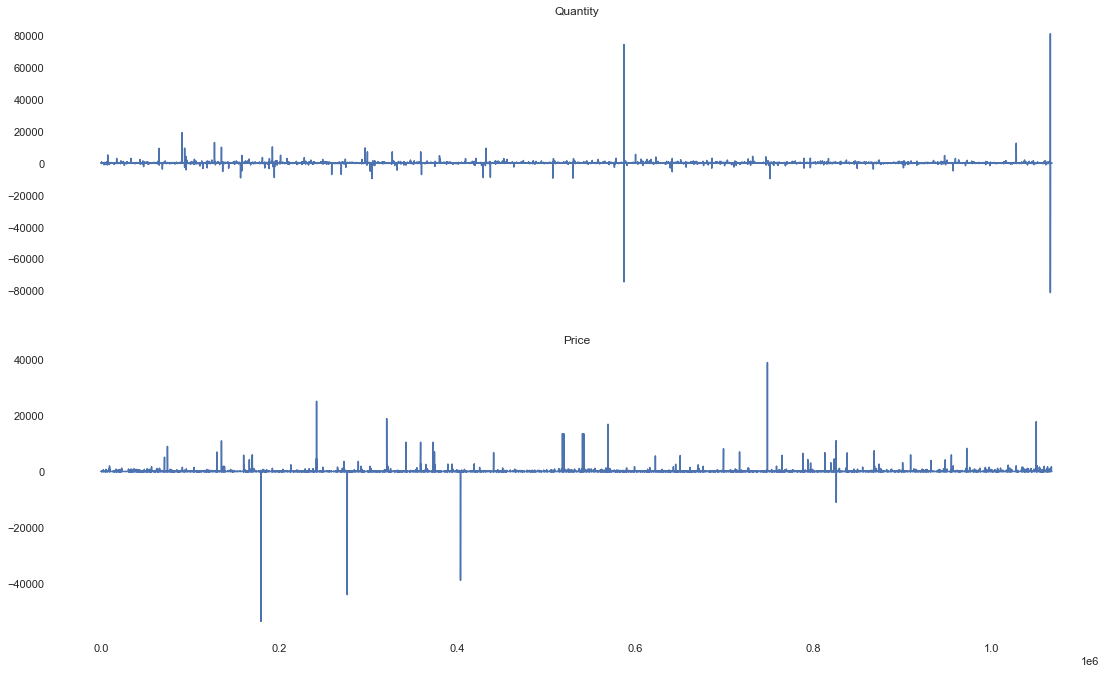

In [6]:
# Checking the distribution of the numerical columns (excluding Customer ID because its an identifier variable).
display(Retail_dataset.describe().drop(labels=['Customer ID'], axis=1))

# Plotting the distribution of the numerical columns.
import matplotlib.pyplot as plt

# plt.subplots() outputs a tuple of figure and axes objects
# The code below assigns the fig variable with fig object and axs variable with axes of subplots (multiple axis and subplot) object
fig, axs = plt.subplots(2, 1, sharex = True, figsize = (16,10))

Numerical_columns = ['Quantity', 'Price']

for (ax, y) in zip(axs.flatten(), Numerical_columns):
    ax.set_facecolor('white')
    ax.grid(False)
    ax.plot(Retail_dataset.loc[:, y], )
    ax.set_title(y)

fig.tight_layout(pad = 3.0)

plt.show()

Looking at the maximum values: it is very **unrealistic** of someone buying 80995 units of something **online**. However, **it is possible for an item to cost 38970 sterling (Â£)**. After all, its the seller that determine the price. So, before deciding anything, lets review the business context underlying the dataset.<br>

Based on the business understanding step, it has been mentioned that most of the company customers are **wholesalers**. In addition, the description column values of very costly transactions (transactions that costs more than 5000 sterling to the customer, based on __[the average wage of the UK](https://recruitmentbuzz.co.uk/average-wage-uk-salary-earning-age/)__ as the baseline purchasing power) are mostly filled with POST and MANUAL values.<br>

Therefore, it is inferred that these transactions are very expensive because the customer also pays for the postage/shipping fee (POST stock code) or transportation cost (M stock code) of the order. __[This is a common practice among wholesale retailers](https://www.microsoft.com/en-us/microsoft-365/business-insights-ideas/resources/wholesaling-retailing)__: they buy items in bulks **(very large quantities)**, pay for the entire (whole) of the transaction process, then sell and ship the items (also in bulks) to a third-party business (such as another retail), which sells to the buying public (or end users). Based on the analysis above, **these "outliers" are not removed** as they are not outliers but are actual customer data.<br>

From the plot of the data, there can be seen some negative values. These values may affect model quality, therefore these values should be explored more.

In [7]:
# display orders/rows whose values in the Quantity column are negative or zero
Negative_quantity = Retail_dataset[Retail_dataset['Quantity'] <= 0]
display(Negative_quantity)

# display orders/rows whose values in the Price column are negative or zero
Negative_price = Retail_dataset[Retail_dataset['Price'] <= 0]
display(Negative_price)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
...,...,...,...,...,...,...,...,...
1065910,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,2011-12-09 09:57:00,0.83,14397.0,United Kingdom
1067002,C581499,M,Manual,-1,2011-12-09 10:28:00,224.69,15498.0,United Kingdom
1067176,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,2011-12-09 11:57:00,10.95,15311.0,United Kingdom
1067177,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,2011-12-09 11:58:00,1.25,17315.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
...,...,...,...,...,...,...,...,...
1062442,581234,72817,NaN,27,2011-12-08 10:33:00,0.0,NaN,United Kingdom
1063965,581406,46000M,POLYESTER FILLER PAD 45x45cm,240,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1063966,581406,46000S,POLYESTER FILLER PAD 40x40cm,300,2011-12-08 13:58:00,0.0,NaN,United Kingdom
1064015,581408,85175,NaN,20,2011-12-08 14:06:00,0.0,NaN,United Kingdom


The first output indicates that negative or zero Quantity column values are **cancelled orders** (rows whose Invoice code value start with 'C'). These cancelled orders can be used for feature engineering as they add detail about the behaviour of customers.<br>

The second output indicates that negative or zero Price column values are **missing values** (these rows/orders don't have any value on their Customer ID column). To prevent these missing values from affecting model quality, then these rows must be removed in the data preparation step.

In [8]:
# Defining a function that will return True if the condition stated is satisfied.
def True_if_startswith(iterable, value):
    if iterable.startswith(value):
        return True
    else:
        return False

# Checking whether or not the negative Quantity column values have Invoice code that start with 'C'.
# Make a column of cancellation status based on the returned values of the applied True_if_match function
TnF = Negative_quantity.loc[:, 'Invoice'].apply(True_if_startswith, args=("C",))
Negative_quantity_with_cancel_status = Negative_quantity.copy()
Negative_quantity_with_cancel_status['Cancel_status'] = TnF

# Display the amount of cancelled orders (True values) that have negative Quantity column values
display(Negative_quantity_with_cancel_status['Cancel_status'].value_counts())
print('\n')

# Display the detail of orders that have negative Quantity column values but are not cancelled orders (False values)
display(Negative_quantity_with_cancel_status[Negative_quantity_with_cancel_status['Cancel_status'] == False])
print('\n')

True     19493
False     3457
Name: Cancel_status, dtype: int64

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Cancel_status
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom,False
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom,False
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom,False
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom,False
...,...,...,...,...,...,...,...,...,...
1060794,581210,23395,check,-26,2011-12-07 18:36:00,0.0,NaN,United Kingdom,False
1060796,581212,22578,lost,-1050,2011-12-07 18:38:00,0.0,NaN,United Kingdom,False
1060797,581213,22576,check,-30,2011-12-07 18:38:00,0.0,NaN,United Kingdom,False
1062371,581226,23090,missing,-338,2011-12-08 09:56:00,0.0,NaN,United Kingdom,False


The first output shows that several orders have negative Quantity column values but are not cancelled orders (False values). The second output implies that **those orders/rows come from missing values (orders without registered Customer ID)**. To prevent these missing values from affecting model quality, then these rows must be removed in the data preparation step.

## Summary of data understanding
The Early Data Exploration (EDA) task highlights several problems and details about the data. It mainly adds several tasks to be done during the data preparation step, which are:
1. Change the InvoiceDate column datatype into its appropriate datatype
2. Remove rows with missing values (NaN)

# Data preparation
In this step, the data are prepared and readied to use for fulfilling data mining goals.

## Data selection
There are a lot of metrics to measure attrition rates. However, due to resource constraints, the metric is chosen based on its applicability to the company data. The data have several columns: Invoice, StockCode, Description, Quantity, InvoiceDate, Price, Customer ID, Country. Note that not all of these columns contribute detail about the company customers' attrition rates.<br>

As seen from the Early Data Exploration (EDA) task, **the values of the StockCode and Description column don't have any patterns**. The Description column values consist of product names, product description, whether or not the product is a defect, and many other various details that don't necessarily form a pattern. The values of the StockCode column are StockCodes for the described product in the adjacent Description column, but since the values of the Description column often are not the corresponding product name but rather unnecessary details about the product or order then the values of the StockCode column don't mean anything (a specific code might refer to a product name once, but on another occasion it might refer to other unnecessary detail such as product defect status). Hence, the values of these two columns don't contribute any details about the company customer's behaviour, specifically regarding customer attrition, which is one of the goals that was defined before. Therefore, **both of these columns are excluded** from further data-mining work.<br>

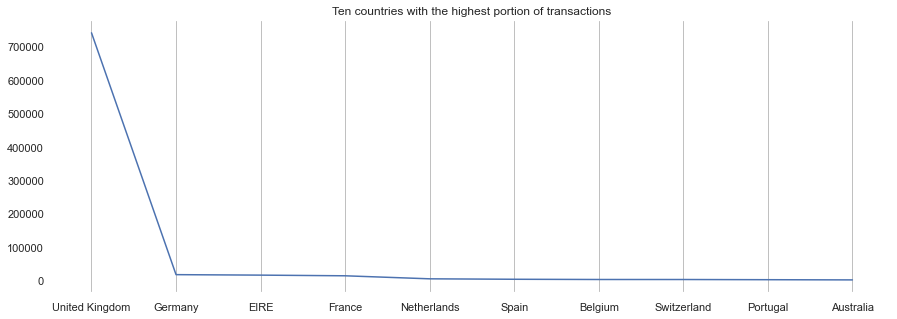

In [9]:
# Group the data then count the amount of transactions by each customer from each country
Number_of_transactions_by_country = Retail_dataset.groupby('Country')['Customer ID'].count()

# Sort by the amount of transactions in each country
Number_of_transactions_by_country = Number_of_transactions_by_country.sort_values(axis = 0, ascending = False, inplace=False, kind='quicksort',
                                                                                  na_position='last', ignore_index=False)

# Plot the data
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (15,5))
ax.grid(color = 'silver', axis = 'x')
ax.grid(b = False, axis = 'y')
ax.set_facecolor('white')
ax.set_title('Ten countries with the highest portion of transactions')
ax = plt.plot(Number_of_transactions_by_country.head(10))

plt.show()

Different countries may have different factors that determine how the customers there behave. However, a huge portion of the company's transactions are made by customers from the United Kingdom. To make sure this imbalance on the proportion of values in the dataset's country column doesn't make further data-mining work to be biased or skewed, then a controlled variable on the country feature must be made. As a huge portion of the company's transactions are housed in the United Kingdom, then **only transaction data from the United Kingdom** are included/selected as a controlled variable.

In [10]:
# Selecting data.
Customer_data = Retail_dataset.loc[:, ['Invoice', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']]
Customer_UK_data = Customer_data[Customer_data['Country'] == 'United Kingdom']
Customer_UK_data

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...
1067350,581585,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
1067351,581586,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
1067352,581586,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
1067353,581586,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


## Data cleaning
Based on the summary of Data understanding step, here are the priorities of the Data cleaning task:
1. Change the InvoiceDate column datatype into its appropriate datatype
2. Remove rows with missing values (NaN)

In [11]:
# Set this particular warning off to prevent false warning, this is caused by Pandas library misinterpretation of the code.
# See the caveat = https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
# See why it should be turned off = https://stackoverflow.com/questions/20625582/how-to-deal-with-settingwithcopywarning-in-pandas
pd.options.mode.chained_assignment = None  # default='warn'

# Changing the InvoiceDate column dtypes into its appropriate dtype.
Customer_UK_data['InvoiceDate'] = pd.to_datetime(Customer_UK_data['InvoiceDate'], format = '%Y-%m-%d %H:%M:%S')
display(Customer_UK_data.dtypes)

Invoice                object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [12]:
# Removing rows with missing values (NaN).
# Create an array that gives information about the number of NaNs in each column
Customer_UK_data_NaN_amounts = Customer_UK_data.isnull().sum(axis = 0)

array_of_columns_names_with_nans = Customer_UK_data_NaN_amounts[Customer_UK_data_NaN_amounts > 0]
list_of_columns_names_with_nans = array_of_columns_names_with_nans.index.tolist()

Nan_Index = []
for names in list_of_columns_names_with_nans:
    NaN_rows = Customer_UK_data[Customer_UK_data[names].isnull()] # Select NaN rows
    Nan_Index.append(NaN_rows.index.tolist()) # Get the NaN rows' indexes

import itertools
from itertools import chain
Flattened_Nan_Index = itertools.chain(*Nan_Index) # Flatten the Nan_Index list so that it wouldnt be a nested list

Customer_UK_data = Customer_UK_data.drop(Flattened_Nan_Index, axis=0)

Customer_UK_data = Customer_UK_data.reset_index().drop('index', axis = 1) # The .drop('index', axis = 1) is used to drop the old index
Customer_UK_data

,Invoice,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom
...,...,...,...,...,...,...
741296,581585,12,2011-12-09 12:31:00,1.95,15804.0,United Kingdom
741297,581586,8,2011-12-09 12:49:00,2.95,13113.0,United Kingdom
741298,581586,24,2011-12-09 12:49:00,1.25,13113.0,United Kingdom
741299,581586,24,2011-12-09 12:49:00,8.95,13113.0,United Kingdom


The Country column can be discarded because it's value is now wholly equal to 'United Kingdom'.

In [13]:
# Discarding the Country column.
Customer_UK_data.drop(columns=['Country'], inplace = True)
Customer_UK_data

,Invoice,Quantity,InvoiceDate,Price,Customer ID
0,489434,12,2009-12-01 07:45:00,6.95,13085.0
1,489434,12,2009-12-01 07:45:00,6.75,13085.0
2,489434,12,2009-12-01 07:45:00,6.75,13085.0
3,489434,48,2009-12-01 07:45:00,2.10,13085.0
4,489434,24,2009-12-01 07:45:00,1.25,13085.0
...,...,...,...,...,...
741296,581585,12,2011-12-09 12:31:00,1.95,15804.0
741297,581586,8,2011-12-09 12:49:00,2.95,13113.0
741298,581586,24,2011-12-09 12:49:00,1.25,13113.0
741299,581586,24,2011-12-09 12:49:00,8.95,13113.0


## Constructing, integrating, or formatting data for modelling prerequisites

### Determine features to use
The cleansed data consist of 5 columns: Quantity of product bought; Invoice number and Invoice Date; Price; and Customer ID. A metric applicable to these kind of data is the __[RFM metric](https://en.wikipedia.org/wiki/RFM_(market_research))__, consisting of =
- Recency – How recently did the customer purchase? ||| Calculated by: based on the values on the InvoiceDate column, calculate how many days have passed by from the date of the most recent transaction by each customer.
- Frequency – How often do they purchase? ||| Calculated by: count the number of invoices made by each customers.
- Monetary Value – How much do they spend? ||| Calculated by: multiplying the Quantity bought column with the Price column: essentially calculating the **revenue** generated from each product that the customer bought to become the Monetary Value of aforementioned customer.<br>

These values provide insight about the company customers' behaviours. Common application of the RFM metric is to become the features used in __[estimating Customer Lifetime Value(CLV)](https://www.sciencedirect.com/science/article/pii/S1877050910003868#:~:text=In%20this%20paper%2C%20customer%20lifetime,a%20health%20and%20beauty%20company.&text=Comparing%20results%20of%20these%20approaches,RFM%20method%20for%20each%20segment)__. By estimating the CLV of each customer, the company can cluster each customers based on their CLV and then identify which cluster/segment of customers has high probability of churning. These inferences can then be used as consideration in making decisions related to the company's CRM strategies. Proper decision making will fulfill the business goal, which in this study case is: **to maintain at least 90% of the company's existing customer bases**.

In [14]:
# Creating a dataframe filled with each customer's Customer ID.
Customer_ids = pd.DataFrame(Customer_UK_data['Customer ID'].unique())
Customer_ids.columns = ['Customer ID']

In [15]:
# Calculating the Recency metric.
# Get the date of the most recent transaction by each customer
Max_purchase_date = Customer_UK_data.groupby('Customer ID').InvoiceDate.max().reset_index()
Max_purchase_date.columns = ['Customer ID', 'MaxPurchaseDate']

# Calculate how many days have passed by from the date of the most recent transaction by each customer
Max_purchase_date['Recency'] = (Max_purchase_date['MaxPurchaseDate'].max() - Max_purchase_date['MaxPurchaseDate']).dt.days

# Merge the dataframes to create a dataframe filled with each customer's Customer ID and the RFM metric
Customer_RFM_metric = pd.merge(Customer_ids, Max_purchase_date[['Customer ID','Recency']], on='Customer ID')
Customer_RFM_metric

,Customer ID,Recency
0,13085.0,157
1,13078.0,0
2,15362.0,448
3,18102.0,0
4,18087.0,97
...,...,...
5405,16000.0,2
5406,15195.0,2
5407,13436.0,1
5408,15520.0,1


In [16]:
# Calculating the Frequency metric.
# Get transactions count for each customer and create a dataframe with it
Customer_frequency = Customer_UK_data.groupby('Customer ID').InvoiceDate.count().reset_index()
Customer_frequency.columns = ['Customer ID','Frequency']
Customer_frequency

# Merge the dataframes to create a dataframe filled with each customer's Customer ID and the RFM metric
Customer_RFM_metric = pd.merge(Customer_RFM_metric, Customer_frequency, on='Customer ID')
Customer_RFM_metric

,Customer ID,Recency,Frequency
0,13085.0,157,92
1,13078.0,0,855
2,15362.0,448,40
3,18102.0,0,1068
4,18087.0,97,95
...,...,...,...
5405,16000.0,2,9
5406,15195.0,2,1
5407,13436.0,1,12
5408,15520.0,1,18


In [17]:
# Calculating the Monetary Value metric.
# Calculate the revenue generated from each transactions
Customer_UK_data['Revenue'] = Customer_UK_data['Quantity'] * Customer_UK_data['Price']

# Calculate the sum of revenue generated from each customer
sum_of_revenue_generated_by_each_customer = Customer_UK_data.groupby('Customer ID')['Revenue'].sum()

# Merge the dataframes to create a dataframe filled with each customer's Customer ID and the RFM metric
Customer_RFM_metric = pd.merge(Customer_RFM_metric, sum_of_revenue_generated_by_each_customer, on='Customer ID')
Customer_RFM_metric

,Customer ID,Recency,Frequency,Revenue
0,13085.0,157,92,1459.46
1,13078.0,0,855,28883.83
2,15362.0,448,40,613.08
3,18102.0,0,1068,598215.22
4,18087.0,97,95,14411.62
...,...,...,...,...
5405,16000.0,2,9,12393.70
5406,15195.0,2,1,3861.00
5407,13436.0,1,12,196.89
5408,15520.0,1,18,343.50


### Determine and fulfill modelling prerequisite
Estimation of CLV has been done through the use of methods from various fields: multi-criteria programming method such as the __[Analytic Hierarchy Process (AHP)](https://www.sciencedirect.com/science/article/pii/S1877050910003868#:~:text=In%20this%20paper%2C%20customer%20lifetime,a%20health%20and%20beauty%20company.&text=Comparing%20results%20of%20these%20approaches,RFM%20method%20for%20each%20segment)__ and data-driven/statistical method  such as __[iterative historical data calculations](https://academicjournals.org/article/article1380724147_Liu%20et%20al.pdf)__. As this study case is simulated solely from a dataset, then expert's judgement, historical data (other than the dataset), and data labels from external sources are not available to use. Hence, instead of estimating the CLV of each customers, unsupervised learning method to mine patterns of customer behaviour is used instead.<br>

Despite not being able to estimate the CLV of each customers, the company can make informed decision regarding what to do in order to maintain at least 90% of its existing customer bases by identifying the patterns of its customer behaviour. Unsupervised cluster analysis algorithms such as __[K-means Clustering](https://ieeexplore.ieee.org/abstract/document/8769171)__ is commonly used to segment customers based on mined patterns from an unlabeled dataset. The company then can tailor-made a retention strategy for each of the customer segments based on the patterns mined from the dataset. With these considerations, then K-means Clustering is chosen as the algorithm that will be used to fulfill the data mining goals.<br>

As a nonparametric algorithm, K-means clustering do not require the population of the data being analyzed meet certain assumptions or parameters (__[Kenton, W 2020](https://www.investopedia.com/terms/n/nonparametric-method.asp)__).

## Review and summary of data preparation

The data is cleansed and the model doesn't have any prerequisite assumptions or parameters.

# Model building

In general, the K-means clustering algorithm is either implemented towards the whole dataset or to each feature of the dataset. Therefore, two models are built: the first being an implementation of the K-means clustering algorithm towards the whole dataset and the latter being an implementation of the K-means clustering algorithm towards each feature of the dataset.

## First Model

The first model implement the K-means clustering algorithm towards the whole dataset. However, Each of the calculated RFM metrics have different unit of measurement with each other. As K-means clustering is a distance-based algorithm, then only measures of location are relevant. To make sure only information about measures of location exist in the data, **the data must be standardized**.

In [18]:
# Creating a numpy equivalent of the dataset values
x = Customer_RFM_metric.iloc[:, 1:].values

# Data standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(x)
x = scaler.transform(x)
x

array([[-0.22016845, -0.13621975, -0.09630758],
       [-0.95915594,  2.17221964,  2.3211131 ],
       [ 1.1495472 , -0.29354459, -0.17091482],
       ...,
       [-0.95444901, -0.37825796, -0.2076014 ],
       [-0.95444901, -0.36010509, -0.19467793],
       [-0.95915594, -0.40851273, -0.19322348]])

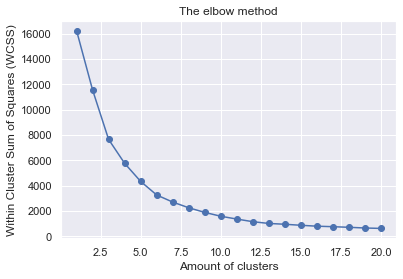

In [19]:
# Finding the optimum number of clusters for K-means classification
from sklearn.cluster import KMeans

# Container for Within Cluster Sum of Squares (WCSS) values
wcss = []

# Run trials to calculate the inertia of the K-means model should it have i amount of clusters
for i in range(1, 21):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_) # then store the model's inertia for each values of i to a container
    
# Plot the results into a line graph
plt.plot(range(1, 21), wcss, marker = 'o')
plt.title('The elbow method')
plt.xlabel('Amount of clusters')
plt.ylabel('Within Cluster Sum of Squares (WCSS)')
plt.show()

From the plot of K-means cluster inertias for each amount of cluster, it is concluded that the optimal amount of clusters is 6.

In [20]:
# Creating the kmeans classifier
kmeans = KMeans(n_clusters = 6, init = 'k-means++', max_iter = 300, n_init = 10, random_state = 0)
y_kmeans = kmeans.fit_predict(x)

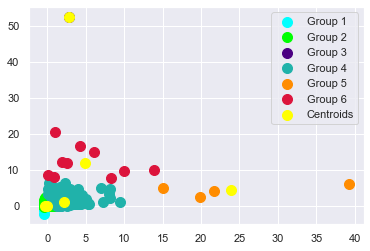

In [21]:
# Visualising the clusters
colors = ['cyan', 'lime', 'indigo', 'lightseagreen', 'darkorange', 'crimson']
labels = ['1', '2', '3', '4', '5', '6']
calculated_clusters = np.unique(y_kmeans)

# x[row_index, col_index] is numpy indexing format
for color, label, calculated_cluster in zip(colors, labels, calculated_clusters):
    plt.scatter(x[y_kmeans == calculated_cluster, 1], x[y_kmeans == calculated_cluster, 2], s = 100,
                c = color,
                label = 'Group {}'.format(label))

#Plotting the centroids of the clusters
plt.scatter(kmeans.cluster_centers_[:, 1], kmeans.cluster_centers_[:, 2], s = 100, c = 'yellow', label = 'Centroids')

plt.legend()

The K-means clustering approach towards the whole dataset and its plot does not clearly show the boundries between clusters and does not handle outliers very well.

## Second Model

### Recency metric clustering

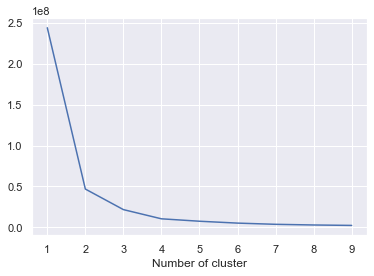

In [22]:
# Finding the optimum number of clusters for K-means classification
from sklearn.cluster import KMeans

# Container for Within Cluster Sum of Squares (WCSS) values
wcss = {}

Recencies_data = Customer_RFM_metric[['Recency']]
for k in range(1, 10):
    kmeans = KMeans(n_clusters = k, init = 'k-means++', max_iter = 500, n_init = 10, random_state = 0).fit(Recencies_data)
    Recencies_data["clusters"] = kmeans.labels_
    wcss[k] = kmeans.inertia_ 

plt.figure()
plt.plot(list(wcss.keys()), list(wcss.values()))
plt.xlabel("Number of cluster")
plt.show()

In [23]:
# The optimal number of cluster is around 3-4 based on the graph above. Therefore, 4 is the amount of clusters chosen.
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 500, n_init = 10, random_state = 0)
kmeans.fit(Customer_RFM_metric[['Recency']])
Customer_RFM_metric['RecencyCluster'] = kmeans.predict(Customer_RFM_metric[['Recency']])

# Function for ordering cluster numbers:
# to make sure the clustering process is intuitive, the clusters are ordered so that customers with
# high recency, which means a lot of days have passed by from the date of the most recent transaction by aforementioned customers (not recent),
# are put into lower valued clusters.
def order_cluster(cluster_field_name, target_field_name, df, ascending):
    new_cluster_field_name = 'new_' + cluster_field_name
    df_new = df.groupby(cluster_field_name)[target_field_name].mean().reset_index()
    df_new = df_new.sort_values(by = target_field_name,ascending=ascending).reset_index(drop = True)
    df_new['index'] = df_new.index
    df_final = pd.merge(df,df_new[[cluster_field_name,'index']], on=cluster_field_name)
    df_final = df_final.drop([cluster_field_name],axis=1)
    df_final = df_final.rename(columns={"index":cluster_field_name})
    return df_final

Customer_RFM_metric = order_cluster('RecencyCluster', 'Recency', Customer_RFM_metric, False)
Customer_RFM_metric

,Customer ID,Recency,Frequency,Revenue,RecencyCluster
0,13085.0,157,92,1459.46,2
1,16714.0,218,120,1254.71,2
2,17984.0,144,251,1191.27,2
3,16955.0,184,60,1261.16,2
4,18037.0,153,33,167.42,2
...,...,...,...,...,...
5405,16443.0,520,1,162.24,0
5406,17129.0,519,2,31.85,0
5407,16649.0,519,20,306.58,0
5408,15056.0,519,7,133.45,0


,count,mean,std,min,25%,50%,75%,max
RecencyCluster,,,,,,,,
0,618.0,622.707120,64.901521,518.0,568.25,618.0,672.75,738.0
1,1026.0,412.626706,46.929319,313.0,380.00,409.0,441.00,517.0
2,901.0,211.987791,53.789145,125.0,167.00,210.0,259.00,312.0
3,2865.0,36.033508,31.479336,0.0,9.00,27.0,57.00,124.0


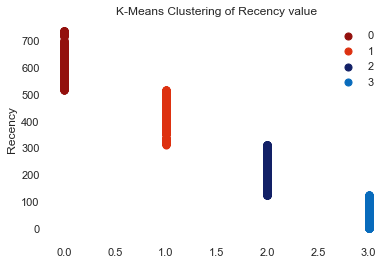

In [24]:
# See details of each cluster's Recency
display(Customer_RFM_metric.groupby('RecencyCluster')['Recency'].describe())

# Visualizing K-mean clustering results
fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.set_title('K-Means Clustering of Recency value')
ax1.set_facecolor("None")
ax1.grid(False)

scatter_x = Customer_RFM_metric['RecencyCluster']
scatter_y = Customer_RFM_metric['Recency']
ax1.set_ylabel(scatter_y.name)

# group for legend based on
Color = Customer_RFM_metric['RecencyCluster']
group = Color
cdict = {0: '#93100d', 1: '#dd3110', 2: '#122066', 3: '#086bbc'}

for g in np.unique(group):
    index = np.where(group == g)
    ax1 = plt.scatter(x = scatter_x.take(index[0]), y = scatter_y.take(index[0]), c = cdict[g], s=50) # remember to set_label AFTER you plot the data!
    ax1.set_label(g)

plt.legend(edgecolor = 'None', facecolor = 'None')

plt.show()

The scatter plot above show the boundries between clusters: with cluster 0 having high recency (which means **a lot of days** have passed by from the date of the most recent transaction by customers in cluster 0) and cluster 3 low recency (which means customers in cluster 3 **recently** bought the company's products).

### Frequency metric clustering

In [25]:
# k-means with 4 cluster (as the metrics, RFM, correlate with each other, the number of cluster should be the same between R, F, and M metrics)
kmeans = KMeans(n_clusters = 4, init = 'k-means++', max_iter = 500, n_init = 10, random_state = 0)
kmeans.fit(Customer_RFM_metric[['Frequency']])
Customer_RFM_metric['FrequencyCluster'] = kmeans.predict(Customer_RFM_metric[['Frequency']])

# order the frequency cluster
Customer_RFM_metric = order_cluster('FrequencyCluster', 'Frequency',Customer_RFM_metric,True)
display(Customer_RFM_metric)

# see details of each cluster's frequency
print("\n\nSummary of Frequency Cluster")
display(Customer_RFM_metric.groupby('FrequencyCluster')['Frequency'].describe())

,Customer ID,Recency,Frequency,Revenue,RecencyCluster,FrequencyCluster
0,13085.0,157,92,1459.46,2,0
1,16714.0,218,120,1254.71,2,0
2,16955.0,184,60,1261.16,2,0
3,18037.0,153,33,167.42,2,0
4,13711.0,218,103,1632.61,2,0
...,...,...,...,...,...,...
5405,15311.0,0,4717,113513.07,3,3
5406,17841.0,1,13097,69516.19,3,3
5407,14606.0,0,6709,30094.38,3,3
5408,12748.0,0,7307,49970.13,3,3




Summary of Frequency Cluster


,count,mean,std,min,25%,50%,75%,max
FrequencyCluster,,,,,,,,
0,4624.0,61.994161,59.044231,1.0,17.0,41.0,90.00,244.0
1,688.0,423.710756,161.087043,245.0,295.0,374.0,501.25,881.0
2,93.0,1356.655914,548.961242,901.0,1001.0,1152.0,1442.00,3438.0
3,5.0,7391.600000,3365.340221,4717.0,5128.0,6709.0,7307.00,13097.0


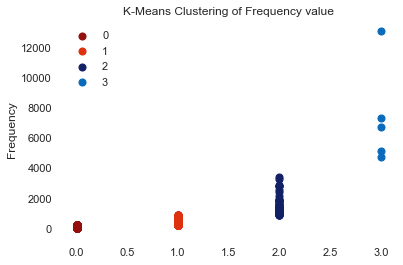

In [26]:
# Visualizing K-mean clustering results

fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.set_title('K-Means Clustering of Frequency value')
ax1.set_facecolor("None")
ax1.grid(False)

scatter_x = Customer_RFM_metric['FrequencyCluster']
scatter_y = Customer_RFM_metric['Frequency']
ax1.set_ylabel(scatter_y.name)

# group for legend based on
Color = Customer_RFM_metric['FrequencyCluster']
group = Color
cdict = {0: '#93100d', 1: '#dd3110', 2: '#122066', 3: '#086bbc'}

for g in np.unique(group):
    index = np.where(group == g)
    ax1 = plt.scatter(x = scatter_x.take(index[0]), y = scatter_y.take(index[0]), c = cdict[g], s=50) # remember to set_label AFTER you plot the data!
    ax1.set_label(g)

plt.legend(edgecolor = 'None', facecolor = 'None')

plt.show()

The scatter plot above show the boundries between clusters: with cluster 0 having low frequency values (which means the customers in cluster 0 **rarely** buy the company's products) and cluster 3 high frequency (which means the customers in cluster 3 **frequently** buy the company's products).

### Monetary value (revenue) metric clustering

In [27]:
# k-means with 4 cluster (as the metrics, RFM, correlate with each other, the number of cluster should be the same between R, F, and M metrics)
kmeans = KMeans(n_clusters=4, init = 'k-means++', max_iter = 500, n_init = 10, random_state = 0)
kmeans.fit(Customer_RFM_metric[['Revenue']])
Customer_RFM_metric['RevenueCluster'] = kmeans.predict(Customer_RFM_metric[['Revenue']])

# order the cluster numbers
Customer_RFM_metric = order_cluster('RevenueCluster', 'Revenue',Customer_RFM_metric,True)
display(Customer_RFM_metric)

# show details of the dataframe
print("\n\nSummary of Revenue Cluster")
display(Customer_RFM_metric.groupby('RevenueCluster')['Revenue'].describe())

,Customer ID,Recency,Frequency,Revenue,RecencyCluster,FrequencyCluster,RevenueCluster
0,13085.0,157,92,1459.46,2,0,0
1,16714.0,218,120,1254.71,2,0,0
2,16955.0,184,60,1261.16,2,0,0
3,18037.0,153,33,167.42,2,0,0
4,13711.0,218,103,1632.61,2,0,0
...,...,...,...,...,...,...,...
5405,13089.0,2,3438,113214.19,3,2,2
5406,13694.0,3,1558,190825.52,3,2,2
5407,14298.0,2,2868,90489.31,3,2,2
5408,15311.0,0,4717,113513.07,3,3,2




Summary of Revenue Cluster


,count,mean,std,min,25%,50%,75%,max
RevenueCluster,,,,,,,,
0,5331.0,1756.194204,2668.194618,-25111.09,310.490,794.410,2014.8050,18745.56
1,68.0,36232.923721,16716.149283,19491.61,23070.275,28771.355,50190.8105,84269.38
2,10.0,138209.769000,47402.942523,90489.31,102475.240,124952.275,164290.0475,233579.39
3,1.0,598215.220000,NaN,598215.22,598215.220,598215.220,598215.2200,598215.22


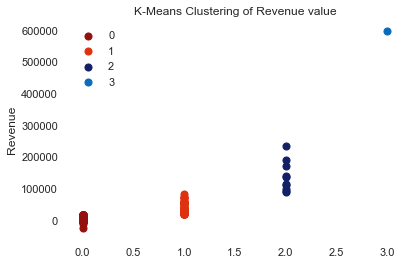

In [28]:
# Visualizing K-mean clustering results

fig = plt.figure()
ax1 = fig.add_subplot(1,1,1)
ax1.set_title('K-Means Clustering of Revenue value')
ax1.set_facecolor("None")
ax1.grid(False)

scatter_x = Customer_RFM_metric['RevenueCluster']
scatter_y = Customer_RFM_metric['Revenue']
ax1.set_ylabel(scatter_y.name)

# group for legend based on
Color = Customer_RFM_metric['RevenueCluster']
group = Color
cdict = {0: '#93100d', 1: '#dd3110', 2: '#122066', 3: '#086bbc'}

for g in np.unique(group):
    index = np.where(group == g)
    ax1 = plt.scatter(x = scatter_x.take(index[0]), y = scatter_y.take(index[0]), c = cdict[g], s=50) # remember to set_label AFTER you plot the data!
    ax1.set_label(g)

plt.legend(edgecolor = 'None', facecolor = 'None')

plt.show()

The scatter plot above show the boundries between clusters: with cluster 0 having low revenue metric (which means the amount of money that customers in cluster 0 spend to purchase the company's products are low) and cluster 3 very high revenue metric (which means the amount of money that customers in cluster 3 spend to purchase the company's products are very high).

### Overall RFM score

Now that the K-means clustering results for the Recency, Frequency, and Monetary value metrics are calculated, those clusters can be summed up to form the overall RFM score for each customers.

In [29]:
Customer_RFM_metric['Overall_RFM_Score'] = Customer_RFM_metric['RecencyCluster'] + Customer_RFM_metric['FrequencyCluster'] + Customer_RFM_metric['RevenueCluster']
Overall_RFM = Customer_RFM_metric.groupby('Overall_RFM_Score')[['Recency','Frequency','Revenue']].mean()
Overall_RFM

,Recency,Frequency,Revenue
Overall_RFM_Score,,,
0,622.939935,22.920455,262.397015
1,413.202797,46.933067,676.014745
2,218.601375,62.891180,1062.971438
3,43.820291,89.686533,1681.780904
4,26.973019,419.893761,6321.240965
5,18.092784,1059.762887,19666.236732
6,7.428571,1302.428571,50771.903810
7,1.777778,4804.111111,101056.454444
8,0.000000,2892.500000,355864.145000


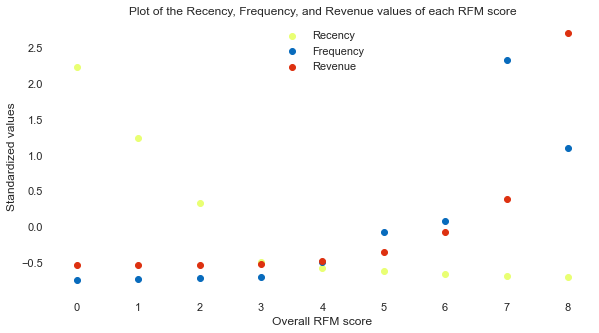

In [30]:
# Visualizing the overall RFM score.
x = Overall_RFM.reset_index()
x = x.iloc[:, :].values
overall_RFM_score = x[:, 0]
plot_data = x[:, 1:]

# Data standardization
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(plot_data)
plot_data = scaler.transform(plot_data)

# plot the scatterplot
import numpy as np
import matplotlib.pyplot as plt

fig = plt.figure(figsize = (10,5))

ax1 = fig.add_subplot(1,1,1)

# remember to set the axes settings BEFORE plotting the data
ax1.set_facecolor("None")
ax1.grid(False)
ax1.set_title('Plot of the Recency, Frequency, and Revenue values of each RFM score')
ax1.set_xlabel('Overall RFM score')
ax1.set_ylabel('Standardized values')

# plot 1 - remember to set plot label after you plot the data
plot_1_data = plot_data[:, 0]
ax1 = plt.scatter(x = overall_RFM_score, y = plot_1_data, s = None, c='#e9ff73', marker="o")
ax1.set_label('Recency')

# plot 2 - remember to set plot label after you plot the data
plot_2_data = plot_data[:, 1]
ax2 = plt.scatter(x = overall_RFM_score, y = plot_2_data, s = None, c='#086bbc', marker="o")
ax2.set_label('Frequency')

# plot 3 - remember to set plot label after you plot the data
plot_3_data = plot_data[:, 2]
ax3 = plt.scatter(x = overall_RFM_score, y = plot_3_data, s = None, c='#dd3110', marker="o")
ax3.set_label('Revenue')

plt.legend(edgecolor = 'None', facecolor = 'None')

# Tweak spacing to prevent clipping of ylabel
plt.subplots_adjust(left=0.15)
plt.show()

Summary of the plot results:
* Customers in cluster 8 **spend more** amount of money than customers in cluster 7 but are **less frequent** in doing transactions with the company compared to the customers in cluster 7.
* Customers in cluster 5-6 have similar characteristics: they **spend less money** and are **less frequent** in doing transactions with the company compared to customers in cluster 7 and cluster 8.
* Customers in cluster 0-4 are more less similar to each other without any seemingly significant differences.

In [31]:
# The final dataframe
display(Customer_RFM_metric)

,Customer ID,Recency,Frequency,Revenue,RecencyCluster,FrequencyCluster,RevenueCluster,Overall_RFM_Score
0,13085.0,157,92,1459.46,2,0,0,2
1,16714.0,218,120,1254.71,2,0,0,2
2,16955.0,184,60,1261.16,2,0,0,2
3,18037.0,153,33,167.42,2,0,0,2
4,13711.0,218,103,1632.61,2,0,0,2
...,...,...,...,...,...,...,...,...
5405,13089.0,2,3438,113214.19,3,2,2,7
5406,13694.0,3,1558,190825.52,3,2,2,7
5407,14298.0,2,2868,90489.31,3,2,2,7
5408,15311.0,0,4717,113513.07,3,3,2,8


# Model results and performance assessment

The first model failed to deliver any inferable description of the data, worsen by the fact that it can't handle outliers. This is inferred by how the model decide to make every outlier data points to become a centroid: **a sign of overfitting**. However, the second model is capable of delivering results that are intuitive and interpretable, especially when being plotted into a scatter plot. Differences and unique characteristics of each clusters are identified and conclusions are inferable: providing the company with information to tailor-made retention strategies to each specific clusters of customers.

# Project conclusion and process evaluation

## Project conclusion

The company now has identified several segments of its customers:
* Cluster 8: high spending customers that only regularly do transactions.
* Cluster 7: more-frequently-purchasing customers that are less willing to spend more money per transaction.
* Cluster 5-6: the medium spender and occasional customers.
* Cluster 0-4: once-in-a-while customers.<br>

The company then can tailor-made retention strategies, such as promotional programs, to each specific clusters of customers, for example:
* Make a rewards points program for customers in cluster 8: for every amount of money they spend, they get some rewards points. This has been done successfully across industries and the prime example of this strategy is __[the visa black card](https://www.cardrates.com/advice/visa-black-cards-requirements/#:~:text=Several%20years%20ago%2C%20the%20Visa,one%20point%20per%20dollar%20spent.)__.
* Maintain the high-frequency of customers in cluster 7 (incentivize repeat business) by making a program: customers are given tier points for every transactions they make. Higher tier provides better rewards or benefits for the customers. This kind of program, usually called "tiered loyalty scheme", are __[prevalent in B2B companies](https://www.crworldwide.com/news-ideas/customer-loyalty/how-can-a-b2b-loyalty-scheme-improve-customer-retention/)__ (same kind of business with the company in this study case).

## Project evaluation

K-means clustering is a convenient algorithm that can be implemented to many types of data. Should more resources become available (e.g. expert suggestions, data labels, etc.), then more advanced algorithms and feature engineering methods are also feasible to be implemented. However, advanced algorithms don't always perform better and models of data created by algorithms should always be compared with each other to determine the best performing model for that specific dataset.

# Afterword

Thank you for reading through this study case. I hope this study case can provide the readers with a brief example of how insights can be extracted from data and how to use said insights in making decisions. Should there be any error from the assumptions or methods that I used, it would be very helpful and I would be very grateful to be notified about it. You can contact me through these channels:
* Gmail: __[andreasparasian@gmail.com](mailto:andreasparasian@gmail.com)__ (general matters) or __[andreas.parasian@ui.ac.id](mailto:andreas.parasian@ui.ac.id)__ (academic matters)
* LinkedIn: https://www.linkedin.com/in/andreasparasian/
* Github: https://torivor.github.io/andreasparasian.github.io/

In [32]:
# Exporting our notebook with custom settings to HTML.
!jupyter nbconvert "Online retail data mining".ipynb --to html --TagRemovePreprocessor.remove_cell_tags="{'remove-cell'}" --TagRemovePreprocessor.remove_input_tags="{'remove-input'}"

[NbConvertApp] Converting notebook Online retail data mining.ipynb to html
[NbConvertApp] Writing 1011802 bytes to Online retail data mining.html
